### Import Dataset

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_15295/3026728138.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df = pd.read_csv("../../dataset/SP500_Historical_Data.csv")

In [3]:
df["Price_Spread"] = df["High"] - df["Low"]
df["Price_Change"] = df["Close"] - df["Open"]

In [4]:
features = ["Price_Spread", "Price_Change", "Volume"]
df[features].values.shape


(2703531, 3)

In [5]:
df[features].values

array([[ 6.910000e+00, -4.030000e+00,  4.674353e+06],
       [ 2.470000e+00, -9.700000e-01,  4.765083e+06],
       [ 3.700000e+00, -2.320000e+00,  5.758642e+06],
       ...,
       [ 8.260000e+00,  4.780000e+00,  2.542100e+06],
       [ 5.800000e+00, -6.500000e-01,  3.337100e+06],
       [ 1.294000e+01, -7.250000e+00,  3.257400e+06]])

### Scaling Features

In [6]:
import math

In [7]:
def scale(data_list):
    n = len(data_list)
    # Step 1: mean data list
    mean = sum(data_list) / n
    # Step 2: sum squared difference
    sum_squared_diff = sum((item - mean) ** 2 for item in data_list)
    # Step 3: standard deviation
    std = math.sqrt(sum_squared_diff / n)
    # Step 4: scaled data list
    scaled_data_list = [(item - mean) / std for item in data_list]

    return scaled_data_list

In [8]:
X_original = df[features].values

In [9]:
price_spread_set = X_original[:, 0]
price_change_set = X_original[:, 1]
volume_set = X_original[:, 2]

In [10]:
scaled_price_spread_set = scale(price_spread_set)
scaled_price_change_set = scale(price_change_set)
scaled_volume_set = scale(volume_set)

In [11]:
df_scaled_set = pd.DataFrame(
    {
        "Ticker": df["Ticker"].values,
        "Date": df["Date"].values,
        "Price_Spread": scaled_price_spread_set, 
        "Price_Change": scaled_price_change_set, 
        "Adj Close": df["Adj Close"].values,
        "Volume": scaled_volume_set
    }
)

In [12]:
df_scaled_set

,Ticker,Date,Price_Spread,Price_Change,Adj Close,Volume
0,A,2000-01-03,1.263718,-1.522055,43.04,-0.082172
1,A,2000-01-04,0.179916,-0.368739,39.75,-0.080327
2,A,2000-01-05,0.480159,-0.877555,37.28,-0.060131
3,A,2000-01-06,0.143301,-0.368739,35.86,-0.125671
4,A,2000-01-07,0.587562,1.334853,38.85,-0.119873
...,...,...,...,...,...,...
2703526,ZS,2026-02-13,1.400414,1.270780,177.72,-0.127710
2703527,ZS,2026-02-17,1.344271,-1.220534,172.59,-0.135760
2703528,ZS,2026-02-18,1.593252,1.798441,172.13,-0.125515
2703529,ZS,2026-02-19,0.992768,-0.248130,168.99,-0.109354


### Visualize Dataset

In [13]:
y_labels = np.where(df_scaled_set["Price_Change"] > 0, 1, -1)
df_scaled_set["Target"] = y_labels

In [14]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

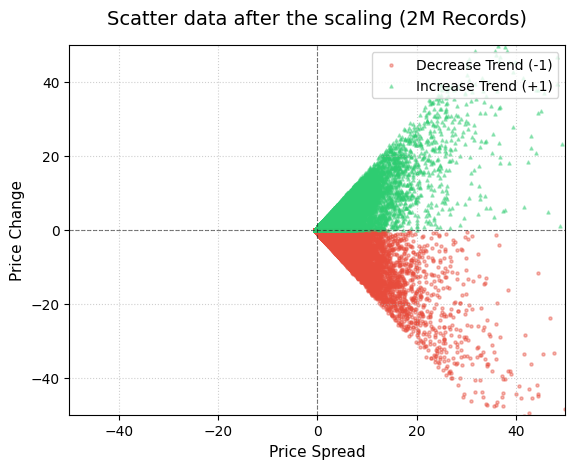

In [15]:
df_decrease = df_scaled_set[df_scaled_set["Target"] == -1]
plt.scatter(
    df_decrease["Price_Spread"],
    df_decrease["Price_Change"],
    s=5,
    color="#e74c3c",
    edgecolors="#e74c3c",
    alpha=0.4,
    label="Decrease Trend (-1)",
    marker="o",
)

df_increase = df_scaled_set[df_scaled_set["Target"] == 1]
plt.scatter(
    df_increase["Price_Spread"],
    df_increase["Price_Change"],
    s=5,
    color="#2ecc71",
    edgecolors="#2ecc71",
    alpha=0.4,
    label="Increase Trend (+1)",
    marker="^",
)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

plt.title("Scatter data after the scaling (2M Records)", fontsize=14, pad=15)
plt.xlabel("Price Spread", fontsize=11)
plt.ylabel("Price Change", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

plt.xlim(-50, 50)
plt.ylim(-50, 50) 

plt.show()

### Topic: The market is experiencing extreme panic and high risk. The system recommends halting all trading to preserve capital.

### Processing Dataset

In [16]:
"""
Market Risk Regime Definition based on 3-Sigma Rule:
- Core Safe Zone: Concentrated around the horizontal axis (0) and extends rightward to Price_Spread ≈ 2.0.
- Outliers / Panic Zone: Data points far to the right (Spread > 3.0).

In quantitative finance, the 3-Sigma Rule dictates that 99.73% of normal trading data falls within [-3, 3].
Any day with a Z-score exceeding 3.0 (the far right edge of the funnel) represents anomalous volatility, 
triggering a 'Panic' status.
"""
df_scaled_set["Risk_Today"] = np.where(
    (df_scaled_set["Price_Spread"] > 3) | (df_scaled_set["Price_Change"] > 3), 
    -1,
    1
)

In [17]:
df_scaled_set["Target_Next_Day"] = df_scaled_set.groupby("Ticker")["Risk_Today"].shift(-1)

In [18]:
df_train_set = df_scaled_set.dropna(subset="Target_Next_Day").copy()
df_train_set["Target_Next_Day"] = df_train_set["Target_Next_Day"].astype(int)

In [19]:
X_3d = df_train_set[["Price_Change", "Price_Spread", "Volume"]]
y_3d = df_train_set[["Target_Next_Day"]]

### Training Data

In [20]:
import SVM as svm

In [21]:
svm_model = svm.SVM(learning_rate=0.001, lambda_param=0.05, epochs=5)

In [22]:
svm_model.fit(X_3d, y_3d)

### Predict Data

In [23]:
result = svm_model.predict(X_3d)
result

array([1., 1., 1., ..., 1., 1., 1.])

In [24]:
df_train_set.shape

(2703059, 9)

In [25]:
# 1. Append tomorrow's prediction results to the original dataframe for easy lookup
df_train_set["Predicted_Risk_Next_Day"] = result

# 2. Calculate the percentage of risk-flagged tickers (-1) per day
# This function counts the number of panic-labeled tickers (-1) divided by the total active tickers for that specific day
market_risk_by_day = (
    df_train_set.groupby("Date")["Predicted_Risk_Next_Day"]
    .apply(lambda x: (x < 0).sum() / len(x) * 100)
    .astype(float)
)

print("Systemic Market Risk Index over time (% of panic-mode tickers):")
print(market_risk_by_day.tail(10))

Systemic Market Risk Index over time (% of panic-mode tickers):
Date
2026-02-05    2.123142
2026-02-06    1.273885
2026-02-09    1.910828
2026-02-10    1.061571
2026-02-11    0.849257
2026-02-12    2.760085
2026-02-13    0.849257
2026-02-17    1.061571
2026-02-18    0.636943
2026-02-19    1.061571
Name: Predicted_Risk_Next_Day, dtype: float64


In [ ]:
market_risk_by_day